# MODELO DE CLASIFICACIÓN DE IMAGENES PARA DETERMINAR NEUMONIA EN PACIENTES CON COVID 19 USANDO REDES NEURONALES CONVOLUCIONALES

## NOMBRE : César Mayta

## DATASET  [KAGGLE](https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/data)

## IMPORTAMOS LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS PATH DE IMAGENES

In [2]:
BASE_DIR = '/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets'

In [3]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/train
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/validation
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/test


## 1 -CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE NORMAL Y PNEUMONIA

In [4]:
C1 = 'normal'
C2 = 'pneumonia'

In [5]:
train_c1_dir = os.path.join(TRAIN_DIR,C1)
train_c2_dir = os.path.join(TRAIN_DIR,C2)

validation_c1_dir = os.path.join(VALIDATION_DIR, C1)
validation_c2_dir = os.path.join(VALIDATION_DIR, C2)

test_c1_dir = os.path.join(TEST_DIR, C1)
test_c2_dir = os.path.join(TEST_DIR, C2)

print(train_c1_dir)
print(train_c2_dir)
print(validation_c1_dir)
print(validation_c2_dir)
print(test_c1_dir)
print(test_c2_dir)

/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/train/normal
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/train/pneumonia
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/validation/normal
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/validation/pneumonia
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/test/normal
/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/test/pneumonia


# MOSTRAMOS UNA IMAGEN

In [6]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

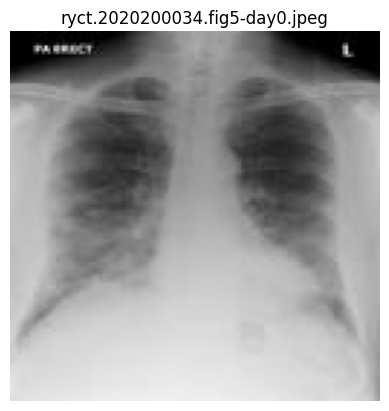

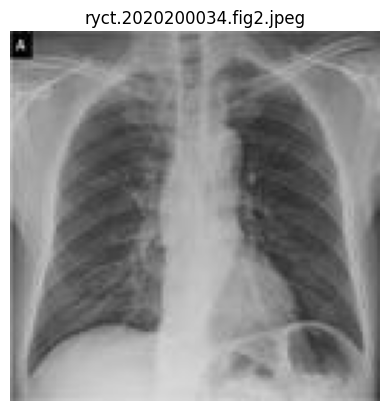

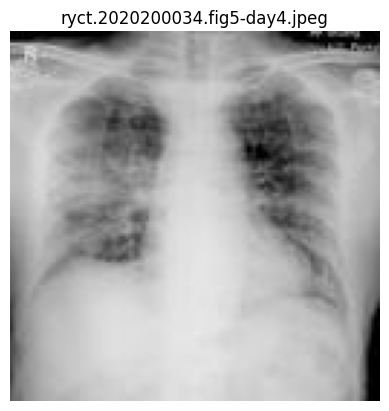

In [7]:
mostrar_imagenes_aleatorias(test_c2_dir,3)

# Mostramos que cantidades de archivos hay en cada carpeta

In [8]:
dataset_dir = [train_c1_dir,train_c2_dir,validation_c1_dir,validation_c2_dir,test_c1_dir,test_c2_dir]
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/train/normal hay 74 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/train/pneumonia hay 74 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/validation/normal hay 27 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/validation/pneumonia hay 27 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/test/normal hay 3 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets/test/pneumonia hay 3 imagenes


# CREAR LA RED NEURONAL CONVOLUCIONAL
